In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

In [4]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df.tail()

Training data shape: (123279, 704)
Training date range: 2018-10-17 to 2023-04-09
Validation data shape: (26357, 699)
Validation date range: 2023-10-25 to 2024-04-14
Test data shape: (26264, 699)
Test date range: 2024-10-23 to 2025-04-13


,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,BLOWOUT_RISK,COMPETITIVE_GAME,TEAM_IMPLIED_PTS,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FTA_ROLLING_AVG_5,TOV_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,percentagePointsFreeThrow_ROLLING_AVG_5,PTS_ROLLING_AVG_7,AST_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FTA_ROLLING_AVG_7,TOV_ROLLING_AVG_7,FG_PCT_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,PACE_ROLLING_AVG_7,PIE_ROLLING_AVG_7,E_OFF_RATING_ROLLING_AVG_7,NET_RATING_ROLLING_AVG_7,TCHS_ROLLING_AVG_7,POSS_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,percentagePointsPaint_ROLLING_AVG_7,percentagePointsMidrange2pt_ROLLING_AVG_7,percentagePoints3pt_ROLLING_AVG_7,percentagePointsFreeThrow_ROLLING_AVG_7,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FTA_ROLLING_AVG_10,TOV_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,percentagePointsFreeThrow_ROLLING_AVG_10,PTS_ROLLING_AVG_15,AST_ROLLING_AVG_15,FGA_ROLLING_AVG_15,FG3A_ROLLING_AVG_15,FTA_ROLLING_AVG_15,TOV_ROLLING_AVG_15,FG_PCT_ROLLING_AVG_15,TS_PCT_ROLLING_AVG_15,USG_PCT_ROLLING_AVG_15,MIN_ROLLING_AVG_15,PACE_ROLLING_AVG_15,PI

In [5]:
top_features = [
    # game context
    'HOME_GAME',
    'STARTING',
    'PLAYER_IS_TEAM_STAR',
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    'spread',
    'TEAM_IMPLIED_PTS',
    
    # player min
    'MIN_LAG_1',
    'MIN_AVG_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    
    # player points
    'PTS_ROLLING_AVG_15',
    'PTS_DELTA_STAR_OUT',
    'MATCHUP_AVG_PTS_LAST_3_TO_DATE',
    'PTS_PER_MIN_X_OPP_DEF_RATING',
    'PTS_PER_MIN_X_USG',
    
    # player context
    'FGA_ROLLING_AVG_5',
    'FGA_LAG_1',
    'MATCHUP_AVG_FGA_LAST_3_TO_DATE',
    'FTA_ROLLING_AVG_40',
    'FT_RATE_ROLLING_AVG_5',
    '3PA_SHARE',
    '3PA_SHARE_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_25',
    'TS_PCT_ROLLING_AVG_10',
    'TS_PCT_ROLLING_AVG_25',
    'EFG_PCT_ROLLING_AVG_10',
    'EFG_PCT_ROLLING_AVG_25',
    'POSS_ROLLING_AVG_10',
    'POSS_ROLLING_AVG_25',
    
    # team context
    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',
    'TEAM_PTS_ROLLING_AVG_3',
    'TEAM_OFF_RATING_ROLLING_AVG_3',
    'TEAM_AST_ROLLING_AVG_3',
    
    # opponent context
    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'OPP_FORWARD_DEF_RATING',
    'OPP_CENTER_DEF_RATING',
]

In [6]:
# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=50,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

# XGBOOST MODEL

### Remove correlated features

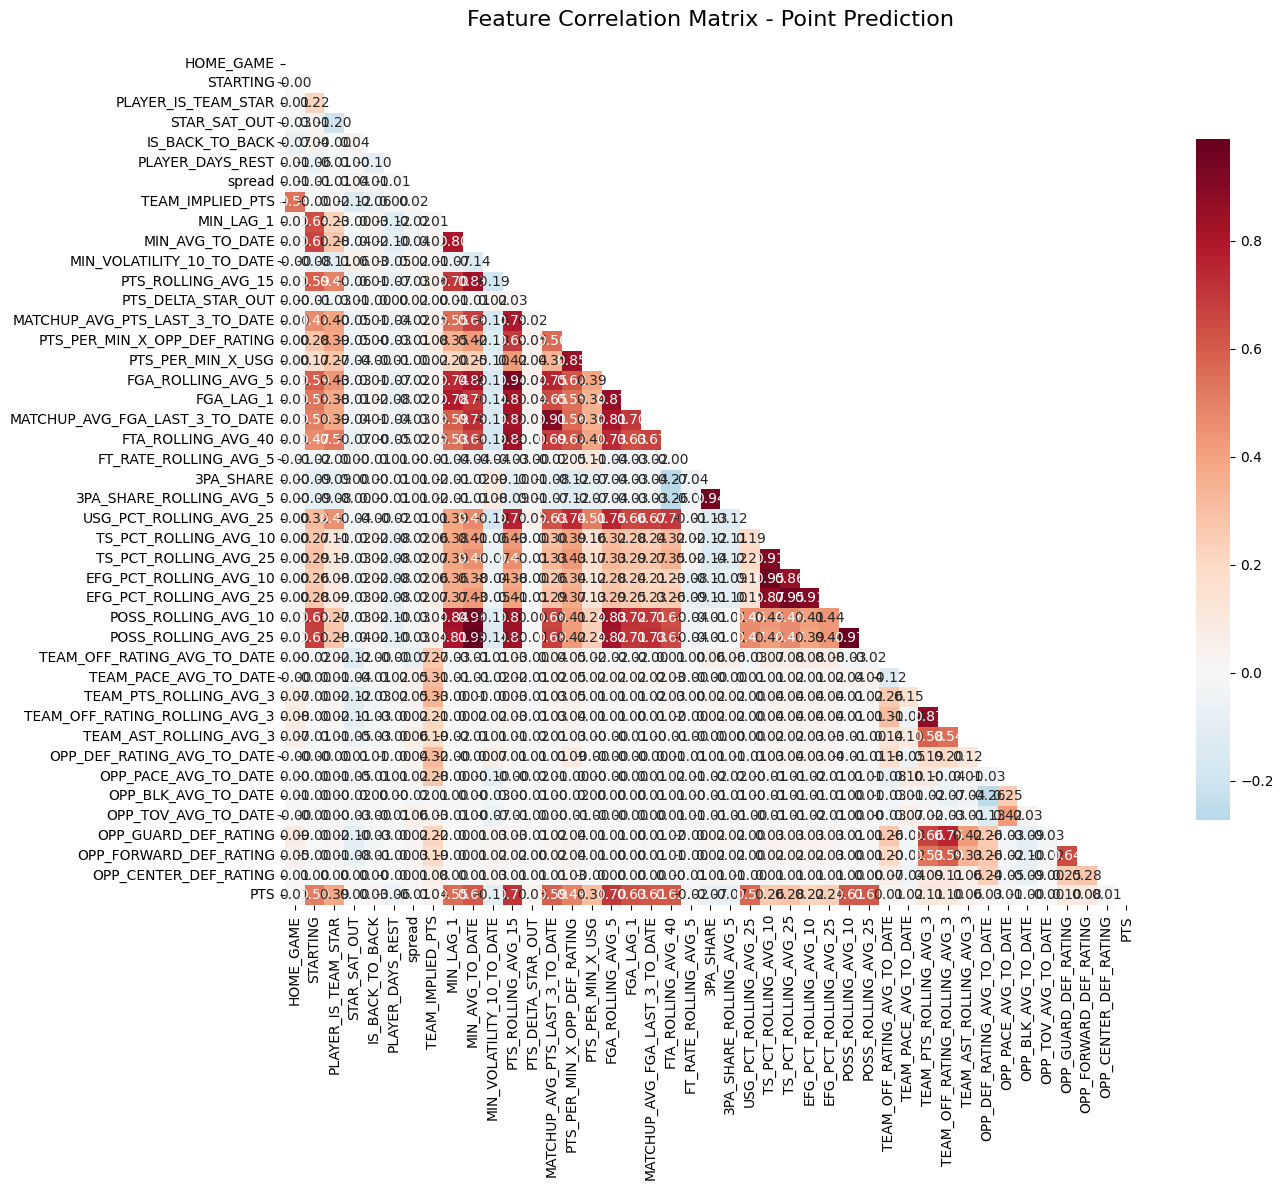

TOP 10 FEATURES MOST CORRELATED WITH PTS:
 1. PTS_ROLLING_AVG_15             0.715
 2. FGA_ROLLING_AVG_5              0.701
 3. FGA_LAG_1                      0.631
 4. FTA_ROLLING_AVG_40             0.617
 5. POSS_ROLLING_AVG_25            0.611
 6. MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.610
 7. MIN_AVG_TO_DATE                0.610
 8. POSS_ROLLING_AVG_10            0.610
 9. MATCHUP_AVG_PTS_LAST_3_TO_DATE 0.586
10. USG_PCT_ROLLING_AVG_25         0.565
REMOVED: MIN_AVG_TO_DATE                (corr with POSS_ROLLING_AVG_25: 0.988)
REMOVED: POSS_ROLLING_AVG_10            (corr with POSS_ROLLING_AVG_25: 0.973)
REMOVED: EFG_PCT_ROLLING_AVG_10         (corr with TS_PCT_ROLLING_AVG_10: 0.954)
REMOVED: EFG_PCT_ROLLING_AVG_25         (corr with TS_PCT_ROLLING_AVG_25: 0.954)

SUMMARY:
Original features: 42
Removed features: 4
Final features: 38


In [7]:
corr_matrix, top_10_features = simple_correlation_analysis(train_df, top_features)

top_features = remove_highly_correlated_features(train_df, top_features, threshold=0.95)

### Train xgboost model and also using quantile regression

In [8]:
# Standard regression
xgbModel, metrics, _ = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,  
    tune_hyperparams=False,
    tune_iters=200
)

# Quantile regression
xgbModels, val_metrics = fit_quantile_models(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False
)

# Make predictions with quantile models
pred_df = predict_quantiles(xgbModels, test_df, top_features)

# Evaluate quantile models
test_results = evaluate_quantile_models(xgbModels, test_df, top_features, "PTS")

print("=" * 50)
print("STANDARD REGRESSION RESULTS")
print(f"VAL RMSE: {metrics['RMSE']:.2f}")
print(f"VAL MAE: {metrics['MAE']:.2f}")
print(f"VAL R²: {metrics['R2']:.2f}")

print("\n" + "=" * 50)
print("QUANTILE REGRESSION RESULTS")
for quantile_name, results in test_results.items():
    print(f"{quantile_name} Test RMSE: {results['RMSE']:.2f}")
    print(f"{quantile_name} Test MAE: {results['MAE']:.2f}")
    print(f"{quantile_name} Test R²: {results['R2']:.2f}")

print("\n" + "=" * 50)
print("PREDICTION INTERVALS SUMMARY")
print(f"Average q10 (lower bound): {pred_df['q10'].mean():.2f}")
print(f"Average q50 (median): {pred_df['q50'].mean():.2f}")
print(f"Average q90 (upper bound): {pred_df['q90'].mean():.2f}")
print(f"Average interval width: {pred_df['prediction_interval_width'].mean():.2f}")

print("=" * 50)

# Model quality assessment
best_rmse = min([results['RMSE'] for results in test_results.values()])
if best_rmse < 5.5:
    print("EXCELLENT MODEL - Ready for betting!")
elif best_rmse < 6.0:
    print("GOOD MODEL - Solid for betting!")
else:
    print("Model needs improvement")


Training quantile model for q10...
q10 validation RMSE: 8.942

Training quantile model for q50...
q50 validation RMSE: 5.727

Training quantile model for q90...
q90 validation RMSE: 9.008
q10 Test RMSE: 9.040
q50 Test RMSE: 5.919
q90 Test RMSE: 9.601
STANDARD REGRESSION RESULTS
VAL RMSE: 5.69
VAL MAE: 4.35
VAL R²: 0.60

QUANTILE REGRESSION RESULTS
q10 Test RMSE: 9.04
q10 Test MAE: 6.88
q10 Test R²: -0.06
q50 Test RMSE: 5.92
q50 Test MAE: 4.47
q50 Test R²: 0.55
q90 Test RMSE: 9.60
q90 Test MAE: 8.06
q90 Test R²: -0.19

PREDICTION INTERVALS SUMMARY
Average q10 (lower bound): 4.25
Average q50 (median): 10.18
Average q90 (upper bound): 17.90
Average interval width: 13.65
GOOD MODEL - Solid for betting!


### Evaluate pinball loss on out-of-time data

In [9]:
def validate_out_of_time_pinball_loss(models, test_df, features, target_col='PTS'):
    """
    Validate quantile models using pinball loss on out-of-time test data.
    This is the proper way to evaluate quantile regression models.
    """
    import numpy as np
    import pandas as pd
    
    X_test = test_df[features].copy()
    y_test = test_df[target_col].values
    
    def pinball_loss(y_true, y_pred, quantile):
        """Calculate pinball loss for a specific quantile."""
        error = y_true - y_pred
        return np.mean(np.maximum(quantile * error, (quantile - 1) * error))
    
    print("OUT-OF-TIME PINBALL LOSS VALIDATION")
    print("=" * 60)
    print(f"Test set size: {len(y_test)} samples")
    print(f"Date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
    
    results = {}
    quantiles = [0.1, 0.5, 0.9]  # q10, q50, q90
    
    for q in quantiles:
        quantile_name = f'q{int(q*100)}'
        if quantile_name not in models:
            continue
            
        # Get predictions
        preds = models[quantile_name].predict(X_test)
        
        # Calculate pinball loss
        pinball = pinball_loss(y_test, preds, q)
        
        # Calculate other metrics for comparison
        mae = np.mean(np.abs(y_test - preds))
        rmse = np.sqrt(np.mean((y_test - preds) ** 2))
        
        # Calculate coverage (for quantile validation)
        if q == 0.1:
            coverage = np.mean(y_test >= preds)
        elif q == 0.9:
            coverage = np.mean(y_test <= preds)
        else:  # q50
            coverage = None
        
        results[quantile_name] = {
            'pinball_loss': pinball,
            'mae': mae,
            'rmse': rmse,
            'coverage': coverage,
            'quantile': q
        }
        
        print(f"\n{quantile_name.upper()} Model:")
        print(f"  Pinball Loss: {pinball:.4f}")
        print(f"  MAE: {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        if coverage is not None:
            print(f"  Coverage: {coverage:.3f} (target: {q:.1f})")
    
    # Calculate average pinball loss
    avg_pinball = np.mean([results[f'q{int(q*100)}']['pinball_loss'] for q in quantiles])
    print(f"\nAverage Pinball Loss: {avg_pinball:.4f}")
    
    # Model quality assessment
    print(f"\nMODEL QUALITY ASSESSMENT:")
    print("-" * 40)
    if avg_pinball < 2.0:
        print("🟢 EXCELLENT - Very reliable uncertainty estimates!")
    elif avg_pinball < 3.0:
        print("🟡 GOOD - Solid uncertainty estimates!")
    elif avg_pinball < 4.0:
        print("🟠 FAIR - Acceptable uncertainty estimates!")
    else:
        print("🔴 POOR - Uncertainty estimates need improvement!")
    
    # Additional validation metrics
    print(f"\nADDITIONAL VALIDATION METRICS:")
    print("-" * 40)
    
    # Check if q10 < q50 < q90 (monotonicity)
    q10_preds = models['q10'].predict(X_test)
    q50_preds = models['q50'].predict(X_test)
    q90_preds = models['q90'].predict(X_test)
    
    monotonic_q10_q50 = np.mean(q10_preds <= q50_preds)
    monotonic_q50_q90 = np.mean(q50_preds <= q90_preds)
    
    print(f"Monotonicity q10 ≤ q50: {monotonic_q10_q50:.3f} (should be ~1.0)")
    print(f"Monotonicity q50 ≤ q90: {monotonic_q50_q90:.3f} (should be ~1.0)")
    
    # Prediction interval width analysis
    interval_width = q90_preds - q10_preds
    print(f"Average 80% interval width: {interval_width.mean():.2f}")
    print(f"Median 80% interval width: {np.median(interval_width):.2f}")
    
    return results

def validate_by_position_pinball_loss(models, test_df, features, target_col='PTS'):
    """
    Validate pinball loss by position to see if models work well for all positions.
    """
    import numpy as np
    
    X_test = test_df[features].copy()
    y_test = test_df[target_col].values
    
    def pinball_loss(y_true, y_pred, quantile):
        error = y_true - y_pred
        return np.mean(np.maximum(quantile * error, (quantile - 1) * error))
    
    position_cols = ['GUARD', 'FORWARD', 'CENTER']
    quantiles = [0.1, 0.5, 0.9]
    
    print("PINBALL LOSS BY POSITION")
    print("=" * 50)
    
    for pos_col in position_cols:
        if pos_col in test_df.columns:
            pos_mask = test_df[pos_col] == 1
            if pos_mask.sum() > 10:  # Only analyze if enough samples
                print(f"\n{pos_col} (n={pos_mask.sum()}):")
                
                pos_X = X_test[pos_mask]
                pos_y = y_test[pos_mask]
                
                for q in quantiles:
                    quantile_name = f'q{int(q*100)}'
                    if quantile_name in models:
                        preds = models[quantile_name].predict(pos_X)
                        pinball = pinball_loss(pos_y, preds, q)
                        print(f"  {quantile_name}: {pinball:.4f}")

# Usage:
# results = validate_out_of_time_pinball_loss(xgbModels, test_df, top_features, 'PTS')
validate_by_position_pinball_loss(xgbModels, test_df, top_features, 'PTS')

PINBALL LOSS BY POSITION

GUARD (n=13521):
  q10: 0.9236
  q50: 2.3393
  q90: 1.1673

FORWARD (n=10139):
  q10: 0.8478
  q50: 2.1430
  q90: 1.0951

CENTER (n=2604):
  q10: 0.7962
  q50: 2.0574
  q90: 1.0427


### Plot SHAP values per position to verify the model leans on the right drivers

QUANTILE SHAP ANALYSIS BY POSITION

Q10 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_15             1.3385
  STARTING                       0.9643
  FGA_ROLLING_AVG_5              0.7176
  POSS_ROLLING_AVG_25            0.2762
  MIN_LAG_1                      0.2381
  FTA_ROLLING_AVG_40             0.1866
  FGA_LAG_1                      0.1758
  PTS_PER_MIN_X_USG              0.1650
  OPP_GUARD_DEF_RATING           0.1604
  TEAM_PTS_ROLLING_AVG_3         0.1402

By Position:
  GUARD (n=13521): PTS_ROLLING_AVG_15 (1.444)
  FORWARD (n=10139): PTS_ROLLING_AVG_15 (1.251)
  CENTER (n=2604): PTS_ROLLING_AVG_15 (1.132)


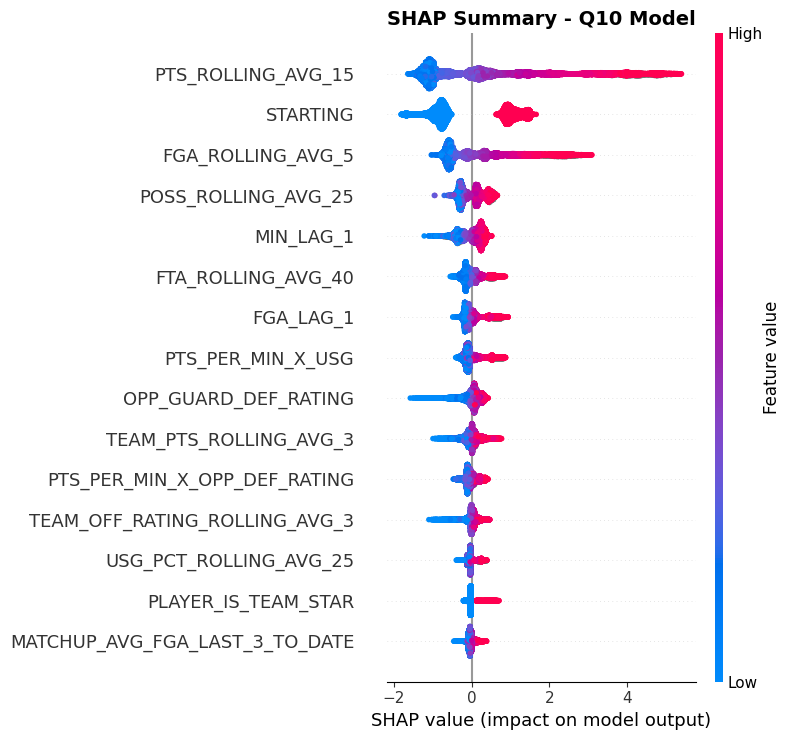


Q50 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_15             2.1159
  FGA_ROLLING_AVG_5              1.2470
  STARTING                       1.1460
  STAR_SAT_OUT                   0.3654
  MIN_LAG_1                      0.3511
  POSS_ROLLING_AVG_25            0.3481
  TEAM_PTS_ROLLING_AVG_3         0.3339
  OPP_GUARD_DEF_RATING           0.2779
  PTS_PER_MIN_X_USG              0.2334
  PTS_PER_MIN_X_OPP_DEF_RATING   0.2322

By Position:
  GUARD (n=13521): PTS_ROLLING_AVG_15 (2.267)
  FORWARD (n=10139): PTS_ROLLING_AVG_15 (1.986)
  CENTER (n=2604): PTS_ROLLING_AVG_15 (1.834)


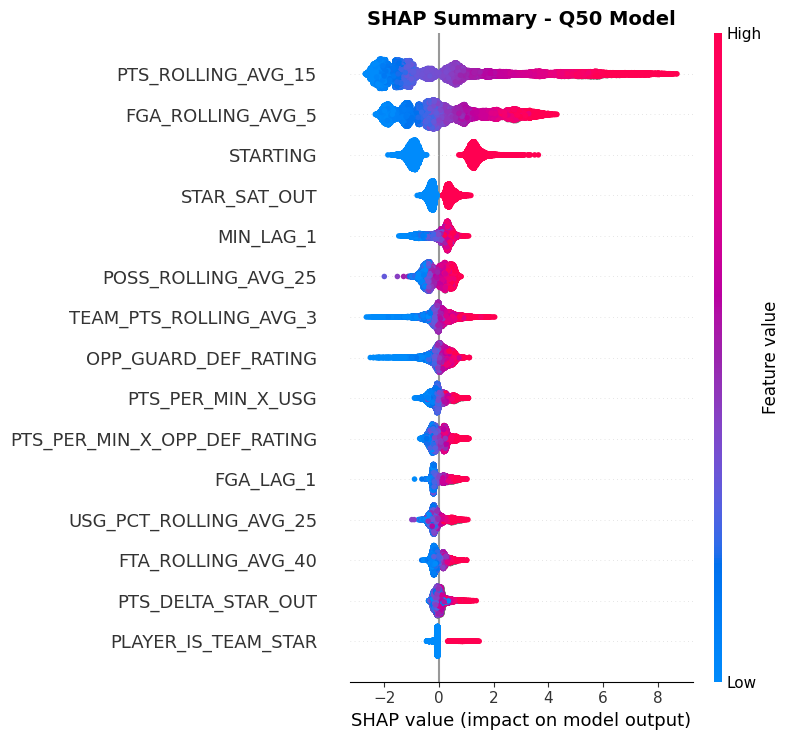


Q90 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_15             2.4763
  FGA_ROLLING_AVG_5              1.6731
  STARTING                       1.3166
  STAR_SAT_OUT                   0.5337
  TEAM_PTS_ROLLING_AVG_3         0.5143
  FGA_LAG_1                      0.4486
  PTS_PER_MIN_X_USG              0.3718
  FTA_ROLLING_AVG_40             0.3467
  OPP_GUARD_DEF_RATING           0.3115
  USG_PCT_ROLLING_AVG_25         0.2809

By Position:
  GUARD (n=13521): PTS_ROLLING_AVG_15 (2.622)
  FORWARD (n=10139): PTS_ROLLING_AVG_15 (2.364)
  CENTER (n=2604): PTS_ROLLING_AVG_15 (2.157)


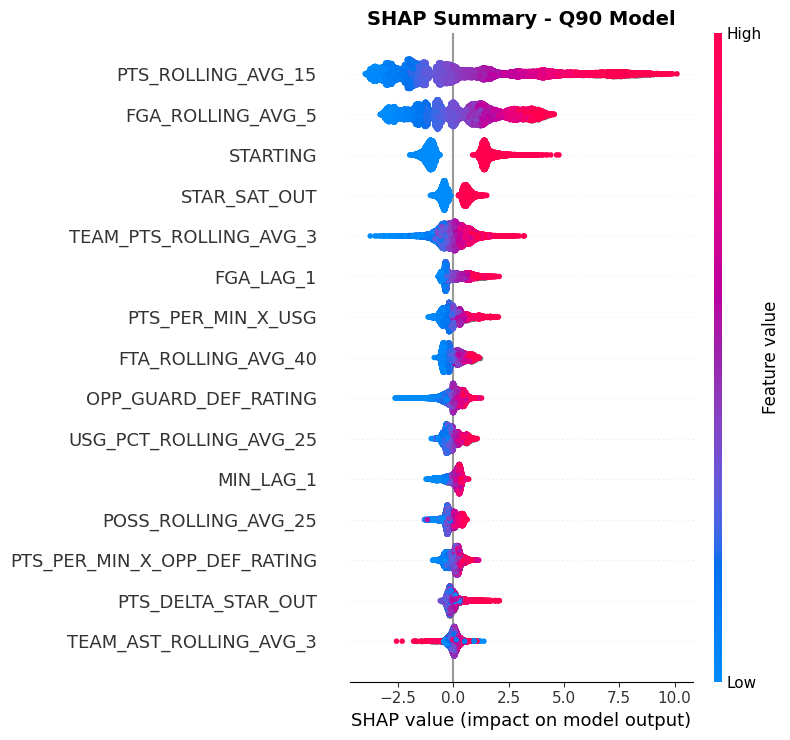

{'q10': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6460723242676091, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='quantile', feature_types=None, feature_weights=None,
              gamma=0.7327236865873834, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01412139968434072,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=414, n_jobs=-1,
              num_parallel_tree=None, ...),
 'q50': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6460723

In [10]:
def analyze_quantile_shap(models, test_df, features, target_col='PTS'):
    """
    Simplified SHAP analysis for quantile models by position (binary columns).
    """
    import shap
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    
    X_test = test_df[features].copy()
    
    # Define position columns
    position_cols = ['GUARD', 'FORWARD', 'CENTER']
    quantiles = ['q10', 'q50', 'q90']
    
    print("QUANTILE SHAP ANALYSIS BY POSITION")
    print("=" * 60)
    
    for quantile in quantiles:
        if quantile not in models:
            continue
            
        print(f"\n{quantile.upper()} MODEL:")
        print("-" * 30)
        
        # Create SHAP explainer
        explainer = shap.TreeExplainer(models[quantile])
        shap_values = explainer.shap_values(X_test)
        
        # Overall top features
        mean_shap = np.abs(shap_values).mean(axis=0)
        feature_importance = pd.DataFrame({
            'feature': features,
            'importance': mean_shap
        }).sort_values('importance', ascending=False)
        
        print("Top 10 Features:")
        for idx, row in feature_importance.head(10).iterrows():
            print(f"  {row['feature']:30} {row['importance']:.4f}")
        
        # Position-specific analysis
        print(f"\nBy Position:")
        for pos_col in position_cols:
            if pos_col in test_df.columns:
                pos_mask = test_df[pos_col] == 1
                if pos_mask.sum() > 0:
                    pos_shap = shap_values[pos_mask]
                    pos_mean_shap = np.abs(pos_shap).mean(axis=0)
                    
                    pos_importance = pd.DataFrame({
                        'feature': features,
                        'importance': pos_mean_shap
                    }).sort_values('importance', ascending=False)
                    
                    print(f"  {pos_col} (n={pos_mask.sum()}): {pos_importance.iloc[0]['feature']} ({pos_importance.iloc[0]['importance']:.3f})")
        
        # Create summary plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, max_display=15, show=False)
        plt.title(f'SHAP Summary - {quantile.upper()} Model', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return models

# Usage:
analyze_quantile_shap(xgbModels, test_df, top_features, 'PTS')

### Check top 20 highest residuals

In [34]:
def get_quantile_residuals(models, test_df, features, target_col='PTS'):
    """
    Get residuals analysis for quantile models.
    """
    import pandas as pd
    import numpy as np
    
    X_test = test_df[features].copy()
    y_test = test_df[target_col].values
    
    # Get predictions from all quantile models
    preds_q10 = models['q10'].predict(X_test)
    preds_q50 = models['q50'].predict(X_test)
    preds_q90 = models['q90'].predict(X_test)
    
    # Create residuals DataFrame
    residuals_df = pd.DataFrame({
        'actual': y_test,
        'pred_q10': preds_q10,
        'pred_q50': preds_q50,
        'pred_q90': preds_q90,
        'residual_q10': y_test - preds_q10,
        'residual_q50': y_test - preds_q50,
        'residual_q90': y_test - preds_q90,
    })
    
    # Add context columns
    context_cols = ["PLAYER_NAME", "MATCHUP", "TEAM_PTS", "OPP_PTS", "STARTING", "MIN", "GUARD", "FORWARD", "CENTER"]
    available_cols = [c for c in context_cols if c in test_df.columns]
    residuals_df = residuals_df.join(test_df[available_cols])
    
    # Add prediction interval analysis
    residuals_df['interval_width'] = preds_q90 - preds_q10
    residuals_df['within_80_interval'] = (y_test >= preds_q10) & (y_test <= preds_q90)
    residuals_df['within_50_interval'] = (y_test >= preds_q10) & (y_test <= preds_q50)
    
    return residuals_df

def analyze_quantile_residuals(models, test_df, features, target_col='PTS'):
    """
    Analyze residuals for quantile models and show worst predictions.
    """
    
    # Get residuals
    residuals_df = get_quantile_residuals(models, test_df, features, target_col)
    
    print("QUANTILE MODEL RESIDUALS ANALYSIS")
    print("=" * 60)
    
    # Overall residuals statistics
    print(f"Q10 Residuals - Mean: {residuals_df['residual_q10'].mean():.3f}, Std: {residuals_df['residual_q10'].std():.3f}")
    print(f"Q50 Residuals - Mean: {residuals_df['residual_q50'].mean():.3f}, Std: {residuals_df['residual_q50'].std():.3f}")
    print(f"Q90 Residuals - Mean: {residuals_df['residual_q90'].mean():.3f}, Std: {residuals_df['residual_q90'].std():.3f}")
    
    # Coverage analysis
    coverage_80 = residuals_df['within_80_interval'].mean()
    coverage_50 = residuals_df['within_50_interval'].mean()
    print(f"\nCoverage Analysis:")
    print(f"80% Interval Coverage: {coverage_80:.3f} (target: 0.80)")
    print(f"50% Interval Coverage: {coverage_50:.3f} (target: 0.50)")
    
    # Worst predictions (largest residuals)
    print(f"\nWORST PREDICTIONS (Q50 - Median):")
    print("-" * 50)
    
    # Sort by absolute residual for q50 (median)
    worst_predictions = residuals_df.copy()
    worst_predictions['abs_residual_q50'] = np.abs(worst_predictions['residual_q50'])
    worst_predictions = worst_predictions.sort_values('abs_residual_q50', ascending=False)
    
    # Show top 20 worst predictions
    top_errors = worst_predictions.head(20)[['PLAYER_NAME', 'MATCHUP', 'actual', 'pred_q50', 'residual_q50', 'MIN', 'GUARD', 'FORWARD', 'CENTER']]
    print(top_errors.to_string(index=False))
    
    return residuals_df

# Usage:
residuals_df = get_quantile_residuals(xgbModels, test_df, top_features, 'PTS')
residuals_df.sort_values('residual_q50', ascending=False).head(10)

,actual,pred_q10,pred_q50,pred_q90,residual_q10,residual_q50,residual_q90,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,MIN,GUARD,FORWARD,CENTER,interval_width,within_80_interval,within_50_interval
11327,43,1.940497,7.770647,14.969419,41.059503,35.229353,28.030581,Pat Connaughton,MIL vs. DET,140,133.0,1,43.57,1,0,0,13.028922,False,False
5783,55,12.536633,20.209333,31.322620,42.463367,34.790667,23.677380,Jamal Murray,DEN vs. POR,132,121.0,1,42.23,1,0,0,18.785988,False,False
18398,60,16.246679,25.685814,35.479355,43.753321,34.314186,24.520645,De'Aaron Fox,SAC vs. MIN,126,130.0,1,44.48,1,0,0,19.232676,False,False
5995,61,18.227461,27.778183,36.187653,42.772539,33.221817,24.812347,Nikola Jokić,DEN vs. MIN,139,140.0,1,52.63,0,0,1,17.960192,False,False
1448,43,3.291889,10.784002,19.740410,39.708111,32.215998,23.259590,Payton Pritchard,BOS vs. POR,128,118.0,0,42.85,1,0,0,16.448521,False,False
10431,41,2.424750,9.319305,18.343475,38.575250,31.680695,22.656525,Jaime Jaquez Jr.,MIA vs. WAS,118,119.0,1,40.53,1,0,0,15.918726,False,False
11656,53,12.441653,21.756247,30.941349,40.558347,31.243753,22.058651,Anthony Edwards,MIN @ DET,105,119.0,1,44.45,1,0,0,18.499695,False,False
6741,56,14.139019,24.854555,35.010063,41.860981,31.145445,20.989937,Stephen Curry,GSW @ ORL,121,115.0,1,34.30,1,0,0,20.871044,False,False
20598,41,3.181032,10.089112,18.249615,37.818968,30.910888,22.750385,Aaron Wiggins,OKC vs. SAC,144,110.0,1,39.88,1,0,0,15.068583,False,False
5417,56,16.886295,26.033798,35.959312,39.113705,29.966202,20.040688,Nikola Jokić,DEN @ WAS,113,122.0,1,38.65,0,0,1,19.073017,False,False


In [ ]:
# Calibrate predicted intervals with isotonic regression or conformal quantiles.
# Betting Layer
# Convert quantiles to normal or skewed-t distribution. Estimate μ = q50, σ ≈ (q90 − q10)/2.56.

# Compute P(over line) for each offered prop.

# Edge = P(model_over) − P(book_over)

# Bet only if Edge > 0.05 (5%) and Kelly_fraction = Edge / Odds_edge_ratio (use 0.25×Kelly).

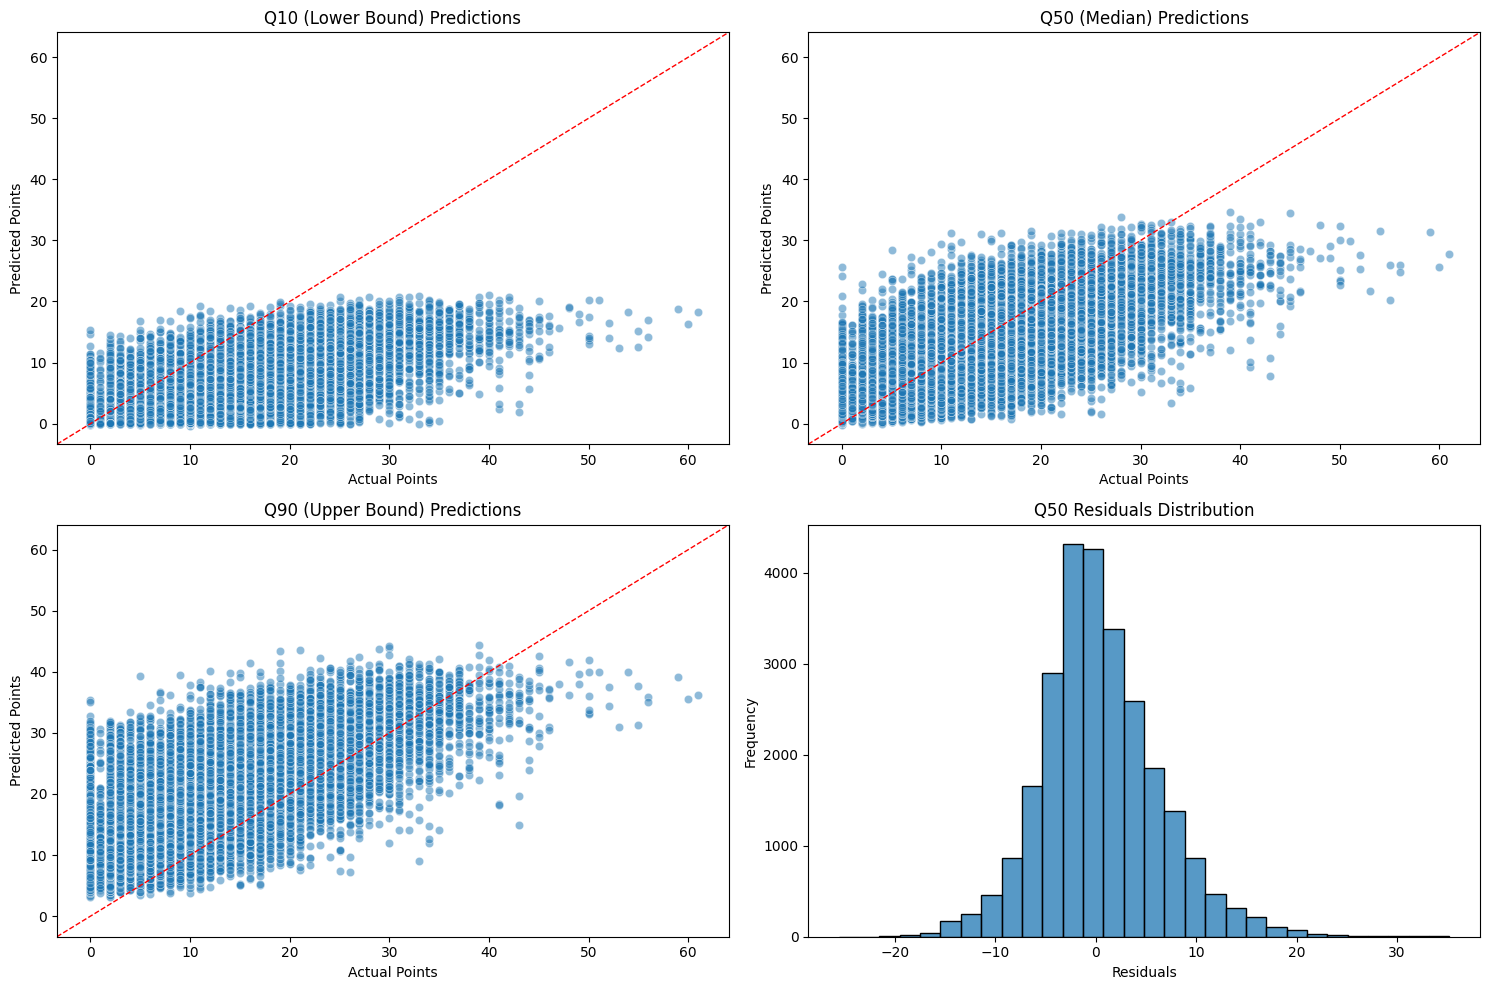

In [31]:
# Enhanced quantile prediction plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Q10 predictions
sns.scatterplot(x='actual', y='pred_q10', data=residuals_df, alpha=0.5, ax=axes[0,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_title('Q10 (Lower Bound) Predictions')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Q50 predictions  
sns.scatterplot(x='actual', y='pred_q50', data=residuals_df, alpha=0.5, ax=axes[0,1])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_title('Q50 (Median) Predictions')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Q90 predictions
sns.scatterplot(x='actual', y='pred_q90', data=residuals_df, alpha=0.5, ax=axes[1,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[1,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[1,0].set_title('Q90 (Upper Bound) Predictions')
axes[1,0].set_xlabel('Actual Points')
axes[1,0].set_ylabel('Predicted Points')

# Residuals distribution
sns.histplot(residuals_df['residual_q50'], bins=30, ax=axes[1,1])
axes[1,1].set_title('Q50 Residuals Distribution')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

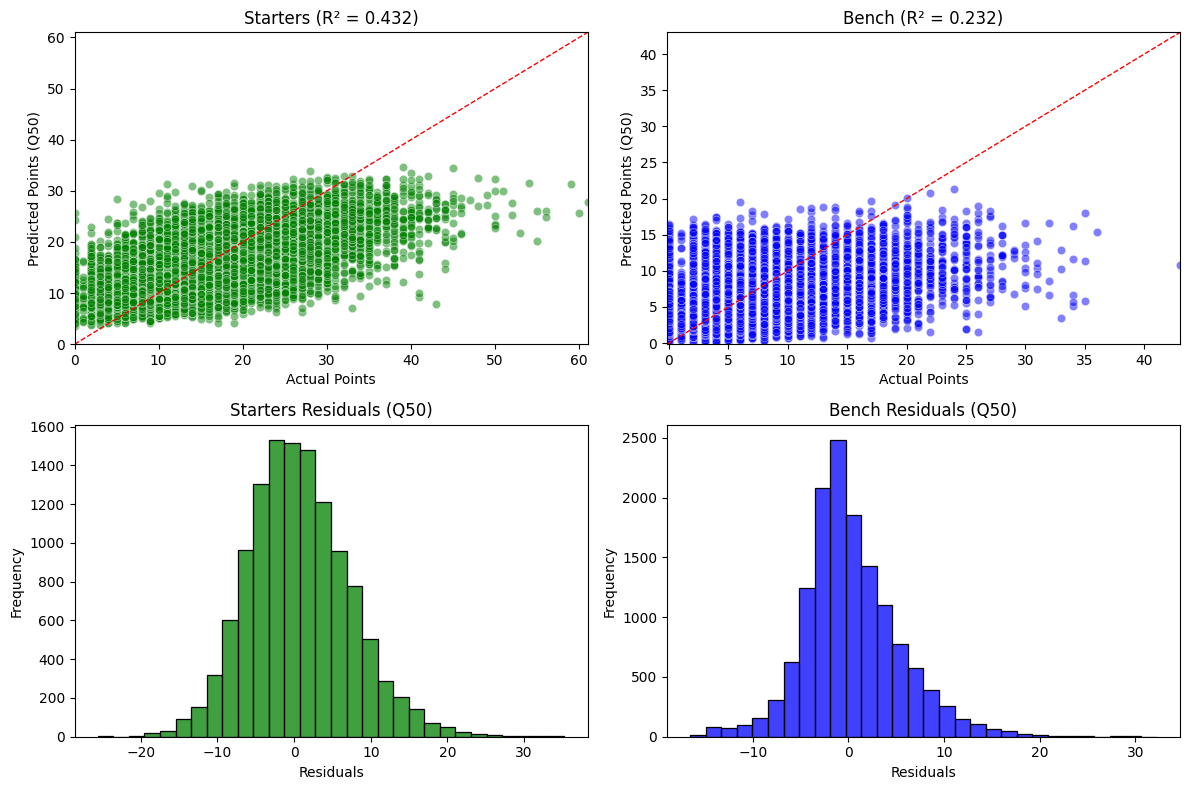

In [32]:
# Get quantile residuals first
residuals_df = get_quantile_residuals(xgbModels, test_df, top_features, 'PTS')

# Split by starting status
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]

# Calculate R² for Q50 (median) predictions
from sklearn.metrics import r2_score
starters_r2 = r2_score(starters['actual'], starters['pred_q50'])
bench_r2 = r2_score(bench['actual'], bench['pred_q50'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

# Starters scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['pred_q50'].min())
maxVal = max(starters['actual'].max(), starters['pred_q50'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points (Q50)')

# Bench scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['pred_q50'].min())
maxVal = max(bench['actual'].max(), bench['pred_q50'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points (Q50)')

# Starters residuals
sns.histplot(starters['residual_q50'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals (Q50)')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

# Bench residuals
sns.histplot(bench['residual_q50'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals (Q50)')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()